# Inspect one MRI across the pipeline: raw → preprocessed → sliced

Visual sanity-check of a single scan — **DICOM series or `.nii`** — at the three pipeline stages:

1. **Raw** — as downloaded (`data/mri/raw/ADNI/.../I<id>/`): a DICOM series folder or a single `.nii` volume, at native resolution.
2. **Preprocessed** — after `mri_preprocessing.py` (standardize → register to atlas → [skull-strip] → crop 100³), saved as `.nii.gz`.
3. **Sliced** — after `mri_preparation.py` (3D→2D coronal slice + augmentation), saved as 100×100 `.npz` arrays.

Set `IMAGE_DATA_ID` below to any scan (both formats are listed in the next cell). Default: `I1553005` (subject `941_S_7051`, CN, DICOM).

In [ ]:
import os
import sys
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Run from the repo root so the relative data/ paths resolve.
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if os.path.basename(os.getcwd()) == '2026_paper':
    os.chdir(REPO_ROOT)
print('Working dir:', os.getcwd())

# Make the library importable and load the shared MRI loader (handles DICOM / .nii.gz / .npz).
sys.path.append(os.path.join(REPO_ROOT, 'src'))
sys.path.append(os.path.join(REPO_ROOT, 'src', 'utils'))
from base_mri import load_mri  # noqa: E402

Working dir: /Users/lucasthim/projects/phd/mmml-alzheimer-diagnosis


## Pick the sample and resolve its path at each stage

In [ ]:
IMAGE_DATA_ID = 'I45108'   # <- any scan id (DICOM or .nii); see the listing cell below
# IMAGE_DATA_ID = 'I1553005'   # <- any scan id (DICOM or .nii); see the listing cell below

RAW_REFERENCE = 'data/reference/DOWNLOAD_RAW_MRI.csv'
PREPROCESSED_DIR = 'data/mri/preprocessed/20260722'
SLICED_DIR = 'data/mri/processed/storage'

# --- Raw: resolve the input path per format (same rule as the preprocessing pipeline) ---
#   DICOM series -> PATH is the I<id> folder (load_mri reassembles it).
#   .nii scan    -> PATH is the folder; the volume is PATH/IMAGE_NAME.
raw_ref = pd.read_csv(RAW_REFERENCE)
row = raw_ref[raw_ref['IMAGE_DATA_ID'] == IMAGE_DATA_ID].iloc[0]
SUBJECT = row['SUBJECT']
FORMAT = str(row['FORMAT']).lower()
if FORMAT == 'dcm':
    raw_path = row['PATH']
else:
    raw_path = os.path.join(row['PATH'], row['IMAGE_NAME'])

# --- Preprocessed: named ADNI_<subject>_<imageid>.nii.gz ---
prep_path = os.path.join(PREPROCESSED_DIR, f'ADNI_{SUBJECT}_{IMAGE_DATA_ID}.nii.gz')

# --- Sliced: all augmented .npz for this image, plus its label from REFERENCE.csv ---
sliced_ref = pd.read_csv(os.path.join(SLICED_DIR, 'REFERENCE.csv'))
sliced_rows = sliced_ref[sliced_ref['IMAGE_DATA_ID'] == IMAGE_DATA_ID]
label = sliced_rows['MACRO_GROUP'].iloc[0] if len(sliced_rows) else None
sliced_paths = sorted(glob.glob(os.path.join(SLICED_DIR, f'ADNI_{SUBJECT}_{IMAGE_DATA_ID}*.npz')))

print(f'Subject: {SUBJECT}  |  Image: {IMAGE_DATA_ID}  |  Label: {label}  |  Format: {FORMAT}')
print(f'Raw          : {raw_path}   (exists: {os.path.exists(raw_path)})')
print(f'Preprocessed : {prep_path}   (exists: {os.path.exists(prep_path)})')
print(f'Sliced       : {len(sliced_paths)} .npz files in {SLICED_DIR}')

Subject: 002_S_0295  |  Image: I45108  |  Label: nan  |  Format: nii
Raw          : data/mri/raw/ADNI/002_S_0295/MPR__GradWarp__B1_Correction__N3__Scaled/2006-04-18_08_20_30.0/I45108/ADNI_002_S_0295_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070319113623975_S13408_I45108.nii   (exists: True)
Preprocessed : data/mri/preprocessed/20260707/ADNI_002_S_0295_I45108.nii.gz   (exists: True)
Sliced       : 12 .npz files in data/mri/processed/sample


In [30]:
# All available scans (both formats) with their label — pick any IMAGE_DATA_ID above.
_labels = sliced_ref.drop_duplicates('IMAGE_DATA_ID').set_index('IMAGE_DATA_ID')['MACRO_GROUP']
_listing = raw_ref[['SUBJECT', 'IMAGE_DATA_ID', 'FORMAT']].copy()
_listing['LABEL'] = _listing['IMAGE_DATA_ID'].map(_labels)
_listing.sort_values(['FORMAT', 'SUBJECT']).reset_index(drop=True)

,SUBJECT,IMAGE_DATA_ID,FORMAT,LABEL
0,033_S_0734,I919238,dcm,CN
1,033_S_4179,I957065,dcm,CN
2,067_S_2304,I901163,dcm,MCI
3,100_S_1286,I959489,dcm,CN
4,941_S_7051,I1553005,dcm,CN
5,941_S_7085,I1600180,dcm,MCI
6,941_S_7106,I1619403,dcm,MCI
7,002_S_0295,I45108,nii,NaN
8,002_S_0413,I45117,nii,NaN
9,002_S_0559,I40674,nii,NaN


## Helper: show three orthogonal mid-slices of a 3D volume

In [31]:
def to_numpy(img):
    """ANTsImage or ndarray -> ndarray."""
    return img.numpy() if hasattr(img, 'numpy') else np.asarray(img)


def show_orthogonal(vol, title):
    """Plot axial / coronal / sagittal mid-slices of a 3D volume, with basic stats."""
    vol = to_numpy(vol)
    print(f'{title}: shape={vol.shape}, dtype={vol.dtype}, '
          f'min={vol.min():.3f}, max={vol.max():.3f}, mean={vol.mean():.3f}, nonzero={np.count_nonzero(vol)}')
    cx, cy, cz = [s // 2 for s in vol.shape]
    planes = [(vol[cx, :, :], f'sagittal @ {cx}'),
              (vol[:, cy, :], f'coronal @ {cy}'),
              (vol[:, :, cz], f'axial @ {cz}')]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    for ax, (plane, name) in zip(axes, planes):
        ax.imshow(plane, cmap='gray')
        ax.set_title(name)
        ax.axis('off')
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

## Stage 1 — Raw scan (DICOM series or `.nii`)

Native resolution, no registration or skull-stripping. `load_mri` reassembles a DICOM series (SimpleITK sorted read → SAR) or reads a single `.nii` directly. Orientation/size differ from the later stages — that is expected.

RAW — I45108 (002_S_0295, nan): shape=(256, 256, 166), dtype=float32, min=0.000, max=2649.902, mean=245.169, nonzero=5808026


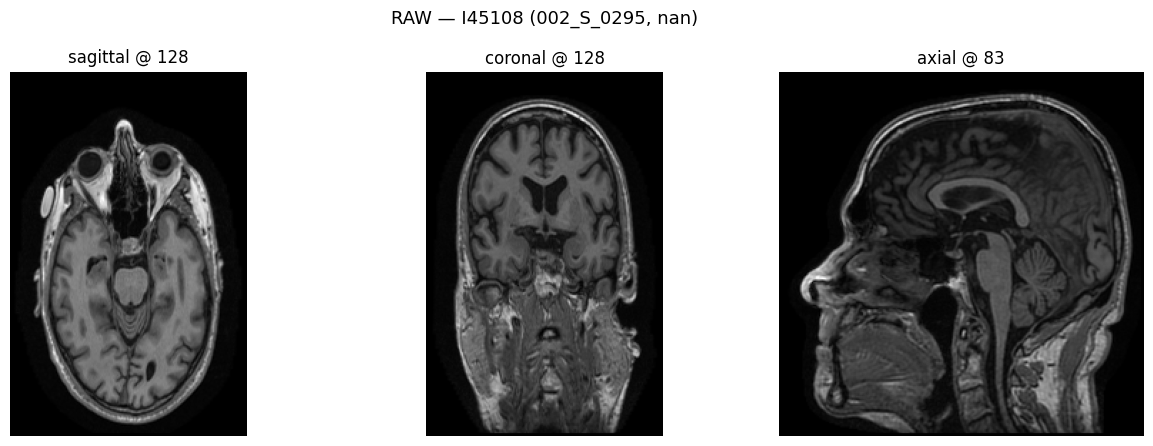

In [32]:
raw_vol = load_mri(path=raw_path, as_ants=True)
show_orthogonal(raw_vol, f'RAW — {IMAGE_DATA_ID} ({SUBJECT}, {label})')

## Stage 2 — Preprocessed volume (100³)

Registered to the atlas and center-cropped to 100×100×100. (This batch was run with `--skip-skull-stripping`, so the skull is still present — expected.)

PREPROCESSED — I45108 (002_S_0295, nan): shape=(100, 100, 100), dtype=float32, min=-0.001, max=18.673, mean=6.151, nonzero=1000000


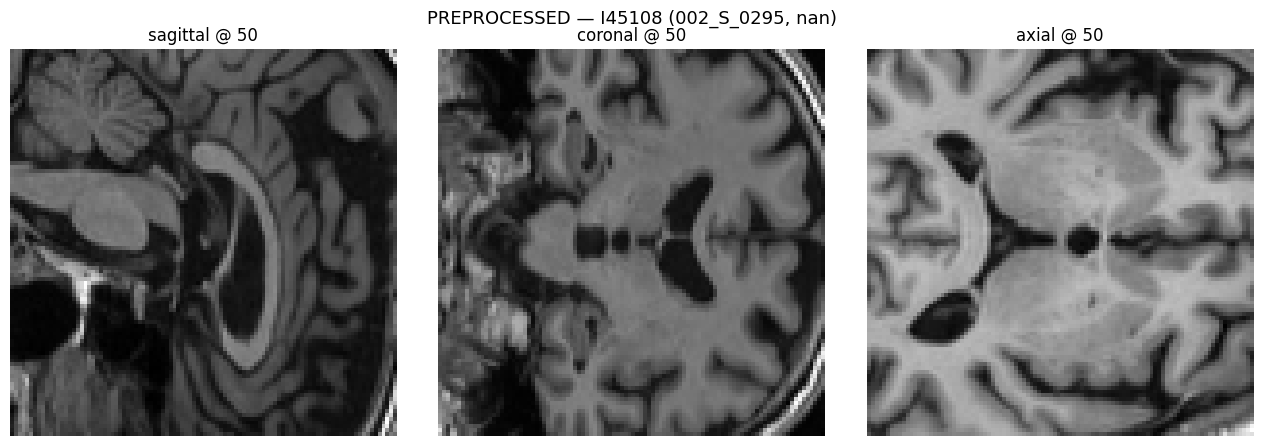

In [33]:
prep_vol = load_mri(path=prep_path, as_ants=True)
show_orthogonal(prep_vol, f'PREPROCESSED — {IMAGE_DATA_ID} ({SUBJECT}, {label})')

## Stage 3 — Sliced 2D images (100×100 `.npz`)

Coronal slices sampled in a neighborhood around slice 50 (here 47/48/50), each with rotation-augmented variants. The base (un-rotated) slices are shown first, then a grid of every augmented `.npz` for this image.

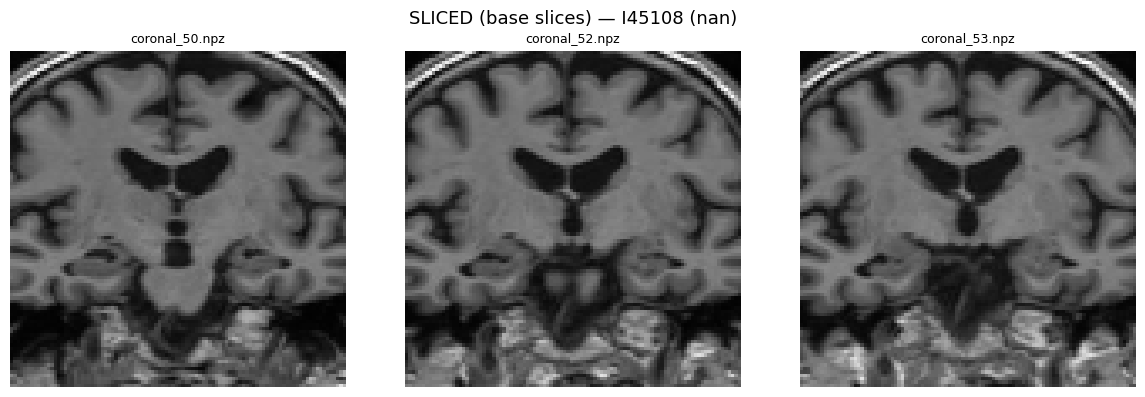

In [34]:
# Base (un-rotated) slices: filenames of the form ..._coronal_<n>.npz with no _rot_ suffix.
base_paths = [p for p in sliced_paths if '_rot_' not in os.path.basename(p)]

fig, axes = plt.subplots(1, max(len(base_paths), 1), figsize=(4 * max(len(base_paths), 1), 4))
if len(base_paths) == 1:
    axes = [axes]
for ax, p in zip(axes, base_paths):
    arr = load_mri(path=p)  # .npz -> 2D ndarray
    ax.imshow(np.rot90(arr,k=2), cmap='gray')
    ax.set_title(os.path.basename(p).replace(f'ADNI_{SUBJECT}_{IMAGE_DATA_ID}_', ''), fontsize=9)
    ax.axis('off')
fig.suptitle(f'SLICED (base slices) — {IMAGE_DATA_ID} ({label})', fontsize=13)
plt.tight_layout()
plt.show()

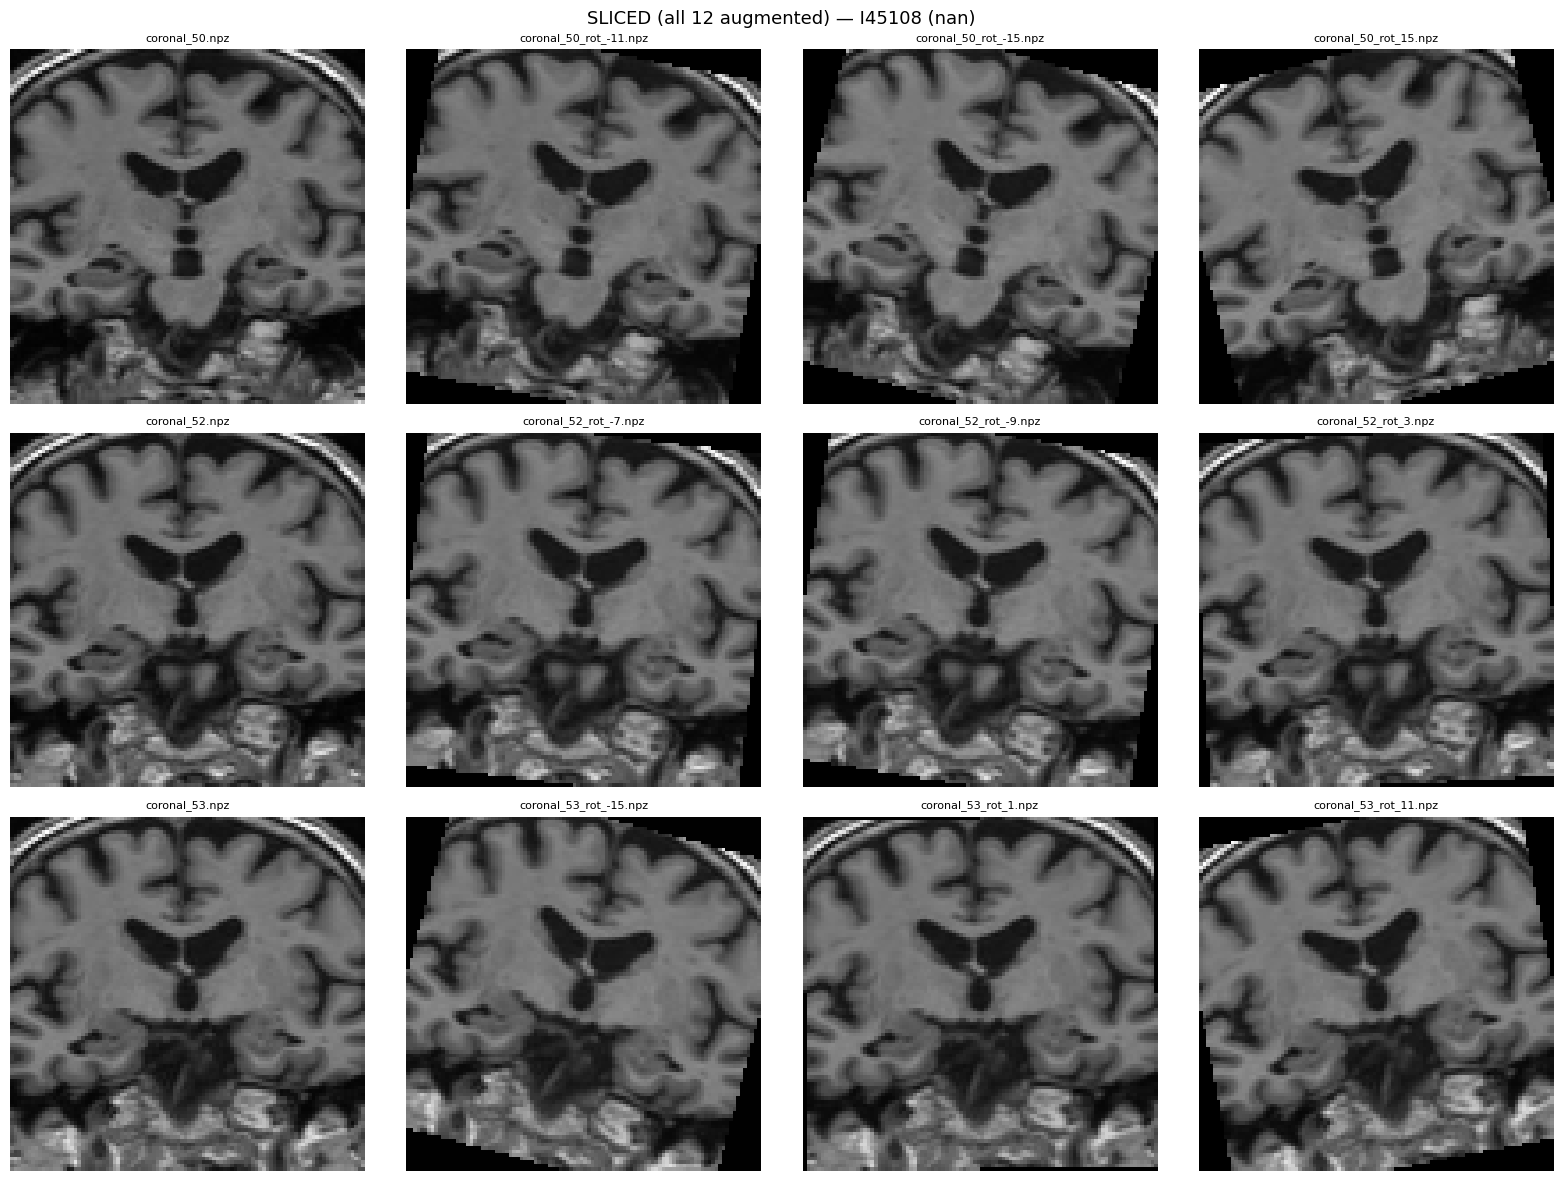

In [35]:
# All augmented slices for this image.
n = len(sliced_paths)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.atleast_1d(axes).ravel()
for ax, p in zip(axes, sliced_paths):
    arr = load_mri(path=p)
    ax.imshow(np.rot90(arr,k=2), cmap='gray')
    ax.set_title(os.path.basename(p).replace(f'ADNI_{SUBJECT}_{IMAGE_DATA_ID}_', ''), fontsize=8)
    ax.axis('off')
for ax in axes[n:]:
    ax.axis('off')
fig.suptitle(f'SLICED (all {n} augmented) — {IMAGE_DATA_ID} ({label})', fontsize=13)
plt.tight_layout()
plt.show()

## Optional — compare the same coronal slice across stages

Take slice 50 from the preprocessed volume directly and put it next to the pipeline's saved base slice, to confirm the 3D→2D step matches what you'd extract by hand.

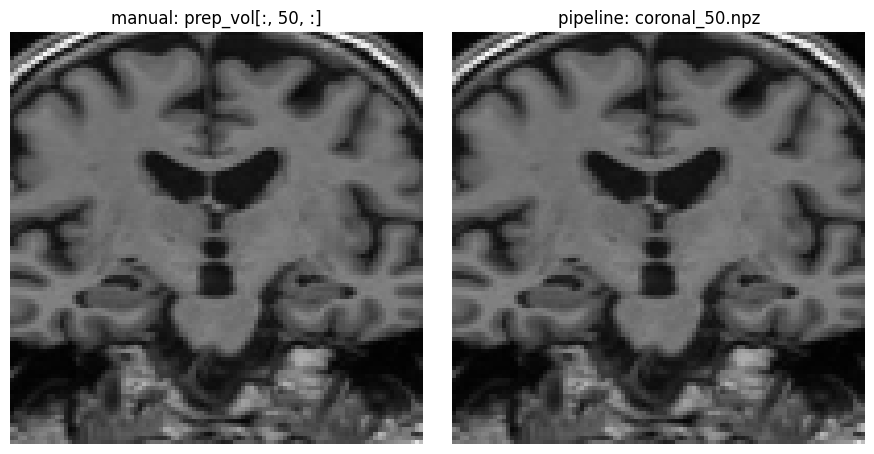

In [36]:
prep_np = to_numpy(prep_vol)
manual_coronal_50 = prep_np[:, 50, :]  # coronal = second axis in this pipeline

saved_base = [p for p in sliced_paths if p.endswith('_coronal_50.npz')]
fig, axes = plt.subplots(1, 2, figsize=(9, 4.5))
axes[0].imshow(np.rot90(manual_coronal_50), cmap='gray') 
# precisei fazer uma rotacao de 90 graus para alinhar a coronal. 
# Preciso rever a rotação das imagens 3D, pq acho que mudou.
axes[0].set_title('manual: prep_vol[:, 50, :]')
axes[0].axis('off')
if saved_base:
    axes[1].imshow(np.rot90(load_mri(path=saved_base[0]),k=2), cmap='gray')
    axes[1].set_title('pipeline: coronal_50.npz')
else:
    axes[1].text(0.5, 0.5, 'no coronal_50.npz\n(check sampled slices)', ha='center', va='center')
axes[1].axis('off')
plt.tight_layout()
plt.show()

# Manually loading DICOM images into memory

In [37]:
import os, sys
import ants
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if os.path.basename(os.getcwd()) == '2026_paper':
    os.chdir(REPO_ROOT)
print('Working dir:', os.getcwd())

# Make the library importable and load the shared MRI loader (handles DICOM / .nii.gz / .npz).
sys.path.append(os.path.join(REPO_ROOT, 'src'))
sys.path.append(os.path.join(REPO_ROOT, 'src', 'utils'))

from base_mri import load_mri, load_dicom_series

Working dir: /Users/lucasthim/projects/phd/mmml-alzheimer-diagnosis


In [38]:
nifti_example_path = "data/mri/raw/ADNI/002_S_0782/MPR__GradWarp__B1_Correction__N3__Scaled/2006-08-14_09_39_47.0/I40717/ADNI_002_S_0782_MR_MPR__GradWarp__B1_Correction__N3__Scaled_Br_20070217003515950_S17835_I40717.nii"
dicom_example_path = "data/mri/raw/ADNI/941_S_7085/Accelerated_Sagittal_MPRAGE/2022-07-01_13_11_36.0/I1600180/"

In [39]:
# Old (broken) reader — stacks frames in file order, shreds ADNI accelerated series:
img_dcm_broken = ants.dicom_read(dicom_example_path)

# Fixed reader — SimpleITK sorted read + reorient to SAR (same as the pipeline's load_mri):
img_dcm = load_dicom_series(dicom_example_path)

img_nii = ants.image_read(nifti_example_path)
print('broken DICOM orientation:', img_dcm_broken.orientation)
print('fixed  DICOM orientation:', img_dcm.orientation, '| NIfTI orientation:', img_nii.orientation)

broken DICOM orientation: ASL
fixed  DICOM orientation: SAR | NIfTI orientation: SAR


In [40]:
img_dcm

ANTsImage (SAR)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (256, 240, 208)
	 Spacing    : (1.0, 1.0, 1.0)
	 Origin     : (-111.5964, -133.494, 113.5181)
	 Direction  : [ 0.  0.  1.  0.  1.  0. -1.  0.  0.]

In [41]:
img_nii

ANTsImage (SAR)
	 Pixel Type : float (float32)
	 Components : 1
	 Dimensions : (256, 256, 166)
	 Spacing    : (0.9477, 0.9436, 1.2022)
	 Origin     : (-100.269, -162.029, 113.756)
	 Direction  : [-0. -0.  1. -0.  1.  0. -1. -0.  0.]

DICOM — load_dicom_series (FIXED: sorted + SAR): shape=(256, 240, 208), dtype=float32, min=0.000, max=923.000, mean=92.767, nonzero=12324735


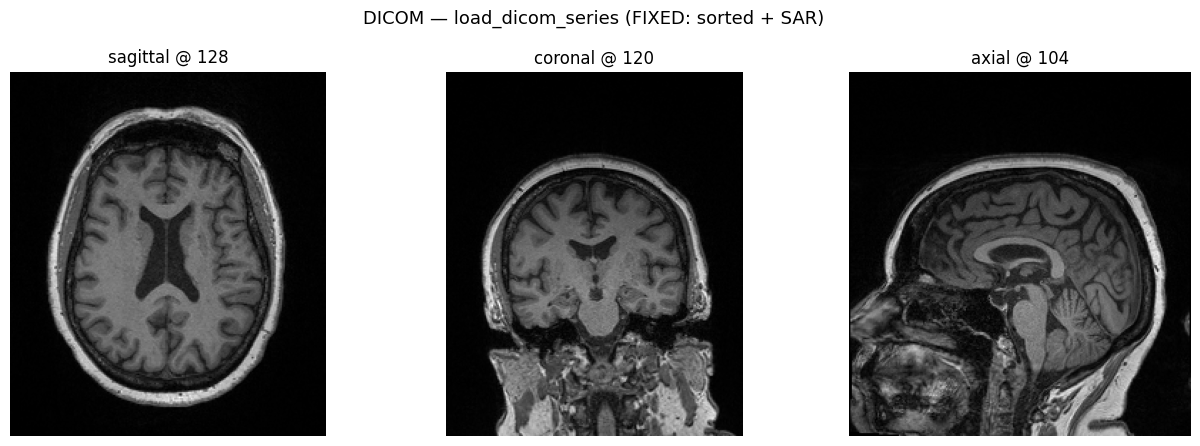

NIfTI read by ANTsPy: shape=(256, 256, 166), dtype=float32, min=0.000, max=4492.352, mean=274.129, nonzero=6800725


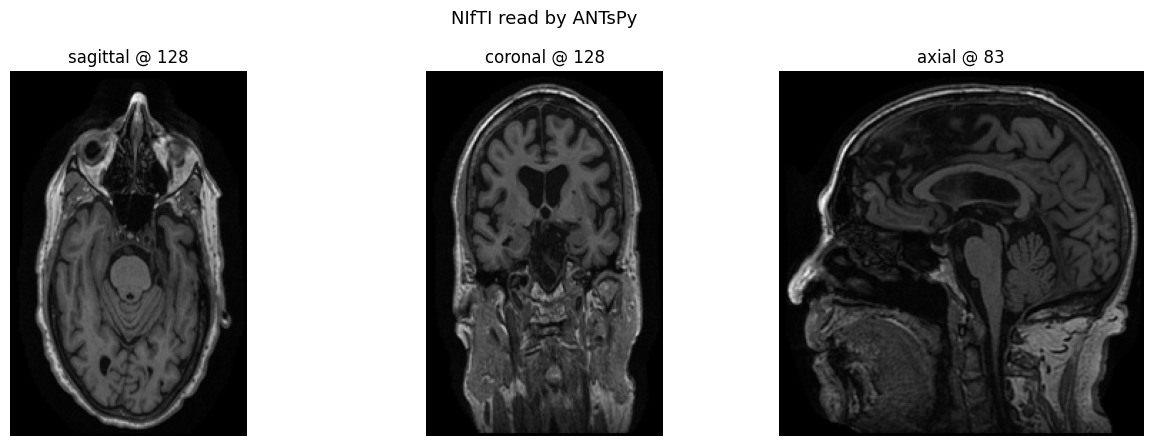

In [42]:
import numpy as np
import matplotlib.pyplot as plt

def to_numpy(img):
    """ANTsImage or ndarray -> ndarray."""
    return img.numpy() if hasattr(img, 'numpy') else np.asarray(img)



def show_orthogonal(vol, title):
    """Plot sagittal / coronal / axial mid-slices of a 3D volume, with basic stats."""
    vol = to_numpy(vol)
    print(f'{title}: shape={vol.shape}, dtype={vol.dtype}, '
          f'min={vol.min():.3f}, max={vol.max():.3f}, mean={vol.mean():.3f}, nonzero={np.count_nonzero(vol)}')
    cx, cy, cz = [s // 2 for s in vol.shape]
    planes = [(vol[cx, :, :], f'sagittal @ {cx}'),
              (vol[:, cy, :], f'coronal @ {cy}'),
              (vol[:, :, cz], f'axial @ {cz}')]
    fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
    for ax, (plane, name) in zip(axes, planes):
        ax.imshow(plane, cmap='gray')
        ax.set_title(name)
        ax.axis('off')
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

show_orthogonal(img_dcm, 'DICOM — load_dicom_series (FIXED: sorted + SAR)')
show_orthogonal(img_nii, 'NIfTI read by ANTsPy')